## Table of Contents
* [Frontmatter] (#frontmatter)
* [Abstract](#abstract)
* [Introduction](#intro)
* [Values Statement](#values-statement)
* [Data Exploration](#data-exploration)
* [Data Cleaning](#data-cleaning)
* [Results](#results)


## Frontmatter <a id="frontmatter"></a>

Diabetes Readmission Predictions Using Machine Learning 
Team: Jayden Chen, Evan Lin, Jonathan Mota
Repo URL: https://github.com/JayBirddy/Middlebury-ML-Class-Proj

## Abstract <a id="abstract"></a>

In this project, we are solving a binary prediction task on diabetic hospital patients and whether they will be readmitted within a 30 day period. Prior work has demonstrated the feasibility of predicting readmission rates within a 30-day period using structured electronic health record data. Namely, one such prominent dataset that has been the subject of a number of research studies is the "Diabetes 130-US Hospitals for Years 1999-2008" dataset. In this project, we train and compare two main binary classifiers: stochastic logistic regression, a basic implementation of a multilayer perception neural networks, as well as two other neural networks with various feature engineerings to see how it would effect results. Beyond standard benchmarking, we employ a demographic fairness audit that looks at model performance across racial, gender, and age subgroups along with a threshold sweep analysis to find the optimal threshold point beyond default 0.5. 

"Discuss findings"

These findings suggest that... not usable for commerical clinical use, ... equity-awareness based evaluations should be considered as part of any deployment pipeline alongside any ethical biases and social inequalities.

## Introduction <a id="introduction"></a>
Your introduction should describe the big-picture problem that you aimed to address in your project. What’s the problem to be solved, and why is it important? As part of your introduction, please include a brief literature review in which you discuss 3 scholarly sources (journal articles or similar) that have attempted similar tasks. Any consistent citation format for the literature review is acceptable.

This project's objective apply broadly to how hospital readmission prediction represents a significant burden, not only on the individual, but also on the health institutions. From the patient's perspective, readmission predictions can make the difference between effective treatment or prolonged health issues, whilst from a hospital or a companies standpoint it may result in wasted resources or financial losses. 

## Values Statement <a id="values-statement"></a>

The primary users of this sort of project would be those that in charge of clinical decision making. Specifically hospital administrators, coordinators, and on-ground physicians who have to manage discharge planning for these diabetic patients. These are the primary positions that would interact directly with a readmission risk score and utlize it to inform decisions regarding whether a patient receives follow-up calls, referrals, or placed under extended observation. Secondary users would include data scientists and quality improvement teams that would test and integrate such a model(s) into existing clinical workflows or other health administrative systems. Beyond direct users, the patients themselves are the primary demographics affected by this technology as it is the one of the direct implicators in their treatment and the interventions they receive despite never engaging at all with the model and its outputs.

The population who stands to gain the most benefit from accurate readmission predictions are patients with complex, high risk diabetes who genuinely need post-discharge support or continued intervention. A well-made model in this case effectively functions as a safety net that can reveal hidden or overlooked details that can prompt interventions that keep these patients from an emergency room visit. Especially with the context of hospitals often being overloaded or very fast-paced, this model doubly acts as a safety net in that regard. Furthermore, hospitals gain to benefit efficiency-wise as healthcare institutions operating at scale can better allocate resources and finances as well as minimize wasted costs.

The populations most at risk of being harmed by this technology, however, are precisely the groups our fairness audit identified as underserved by the model — racial minorities, particularly Black and Hispanic patients, for whom our model demonstrates systematically lower recall. In a clinical deployment, lower recall for a demographic group means that group receives fewer model-triggered interventions relative to their actual risk level. If a hospital trusts the model's output without auditing its subgroup performance, it risks automating a two-tiered standard of care — one in which white patients are more reliably flagged for follow-up than minority patients with equivalent clinical risk. This is not a hypothetical concern. It is a direct consequence of training on historical EHR data that reflects decades of unequal access to care, differential treatment patterns, and inconsistent documentation practices across patient populations. The model does not create these inequities, but an unexamined deployment would operationalize and perpetuate them at scale.

The populations most at risk of harm by this sort of technology are groups that are 

My personal motivation for working on this problem comes from an interest in where algorithmic systems intersect with institutional power. Healthcare is one of the domains where that intersection is most consequential — a model deployed in a hospital is not a neutral tool, it is a policy. It decides, at scale, who gets called back and who gets sent home. Working on this project made that concrete for me in a way that abstract discussions of algorithmic fairness do not. When I computed that our model's recall for one racial subgroup was nearly 15 percentage points lower than for another, those were not just numbers — they represented a proportion of real patients who would be systematically missed. That realization made the fairness audit feel less like an academic extension and more like a basic obligation.

Whether this technology makes the world more equitable depends entirely on how it is used. The model itself is not inherently just or unjust — the equity implications live in the deployment decisions that surround it. A hospital that uses this model with mandatory subgroup auditing, human oversight for high-stakes decisions, and transparent communication to patients about how risk scores influence their care could use it to reduce disparities by catching high-risk patients who would otherwise fall through the cracks. A hospital that deploys it as a black box, trusting aggregate AUROC as a sufficient quality guarantee, risks the opposite. The technical work in this project — particularly the fairness audit and threshold analysis — is an attempt to make the equitable path easier to follow by surfacing the information that responsible deployment requires. Whether that information is acted on is a question of institutional will, not model performance, and that distinction is worth being honest about.

Necessary imports

In [38]:
import pandas as pd
import pickle
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score

## Data Exploration <a id="data-exploration"></a>

In [ ]:
# read the dataset into dataframe
data = pd.read_csv("data/diabetic_data.csv")

In [5]:
# see the size of the dataset 
data.shape

(101766, 50)

In [6]:
# check out data-types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [31]:
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


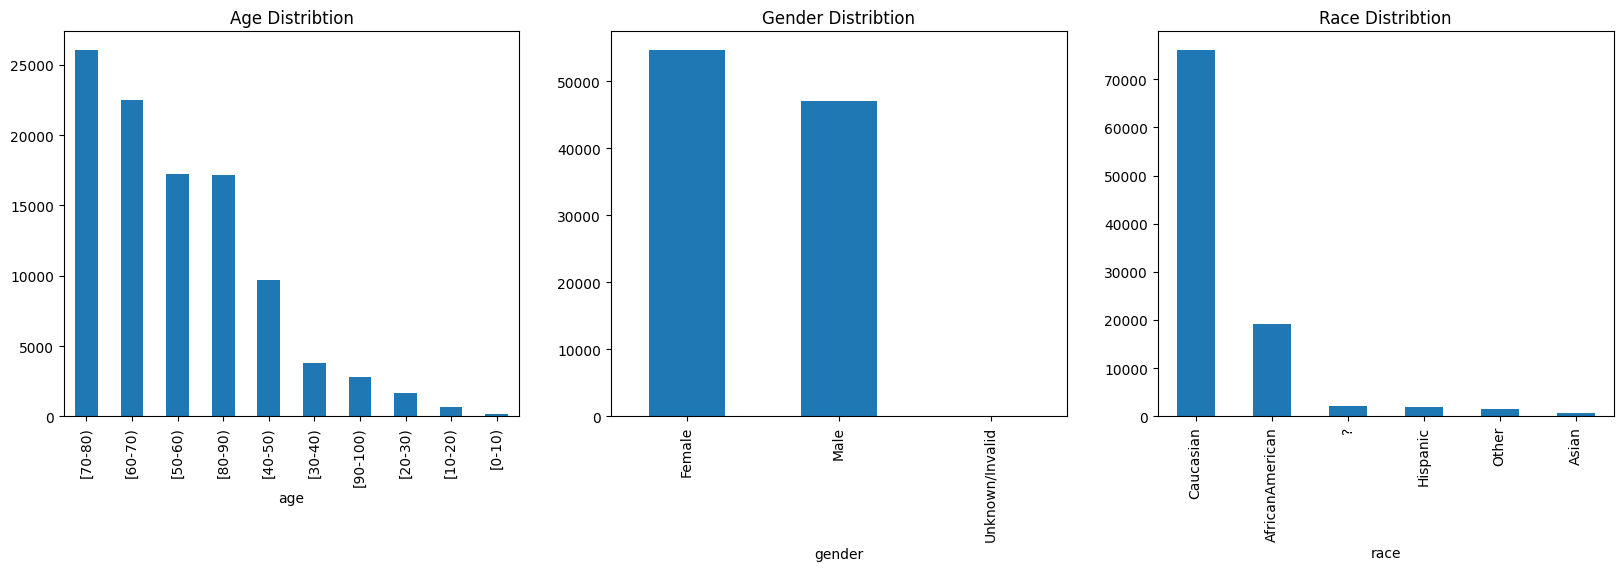

In [43]:
age_count=data["age"].value_counts()
gender_count=data["gender"].value_counts()# Have to deal with unkown/invalid count 
race_count=data["race"].value_counts()
fig,(ax1, ax2, ax3)= plt.subplots(1,3,figsize=(20,5))
_ = age_count.plot(kind='bar',title='Age Distribtion',ax=ax1)
_ = gender_count.plot(kind='bar',title='Gender Distribtion',ax=ax2)
_ = race_count.plot(kind='bar',title='Race Distribtion',ax=ax3)

In [40]:
# check numerical data values 
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [27]:
# make a copy of the file for pre-processing 
train = data.copy(deep=True)

In [ ]:
# if '?' is still a string
train.replace('?', np.nan, inplace=True)

# check missing values
missing_value = (
    train.isnull().mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={"index": "col", 0: "percent_missing"})
      .sort_values("percent_missing", ascending=False)
)
missing_value = missing_value[missing_value["percent_missing"] > 0]
display(missing_value)


,col,percent_missing
5,weight,96.86
22,max_glu_serum,94.75
23,A1Cresult,83.28
11,medical_specialty,49.08
10,payer_code,39.56
2,race,2.23
20,diag_3,1.40
19,diag_2,0.35
18,diag_1,0.02


In [ ]:
# drop the irrelavant and high missing value variables
# weight (97% missing), max_glu_serum (95%), A1Cresult (83%) medical_specialty (49% missing), payer_code (40% missing)
train=train.drop(['weight','max_glu_serum', 'A1Cresult','medical_specialty', 'payer_code'],axis=1)

# drop only missing values in all three diagonosis categories 
train = train.drop(set(train[(train['diag_1']== '?') & (train['diag_2'] == '?') & (train['diag_3'] == '?')].index))

# drop patients who passed after discharge due to non relevant to the readmission prediction task
train = train.drop(set(train[train['discharge_disposition_id']==11].index))

train.shape

(100123, 47)